In [1]:
import sys
sys.path.append("../../src")
sys.path.append("../../data")

import os
import numpy as np
from numba import njit
from scipy.stats import ortho_group
import scipy
from tqdm import tqdm
import matplotlib.pyplot as plt

import logging
from numpy.random import RandomState

from sklearn import cluster, decomposition
from sklearn.datasets import fetch_olivetti_faces

from bss.PredictiveEntropyMax_NMFFace import PredictiveEntropyFaceNMF

# Read Face Images

In [2]:
rng = RandomState(0)

# Display progress logs on stdout
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

faces, _ = fetch_olivetti_faces(return_X_y=True, shuffle=True, random_state=0)
# faces.shape = (400, 4096), values in [0, 1]

# Reshape to image form
faces_img = faces.reshape(-1, 64, 64)

def average_pool_downsample(images, target_size=32):
    """
    Downsample square 64x64 images to target_size x target_size
    using block average pooling.
    target_size must divide 64, e.g. 32 or 16.
    """
    n, h, w = images.shape
    assert h == 64 and w == 64, "Expected 64x64 images."
    assert 64 % target_size == 0, "target_size must divide 64."
    
    factor = 64 // target_size
    return images.reshape(
        n,
        target_size, factor,
        target_size, factor
    ).mean(axis=(2, 4))

# Choose one:
target_size = 16   # good proof-of-concept
# target_size = 16 # faster for debugging

faces_small = average_pool_downsample(faces_img, target_size=target_size)

# Final matrix for your model: (n_features, n_samples)
X_patches = faces_small.reshape(faces_small.shape[0], -1).T.astype(np.float64)

print("Original shape :", faces.shape)         # (400, 4096)
print("Resized images :", faces_small.shape)   # (400, 32, 32) for target_size=32
print("Model matrix   :", X_patches.shape)     # (1024, 400) for target_size=32

Original shape : (400, 4096)
Resized images : (400, 16, 16)
Model matrix   : (256, 400)


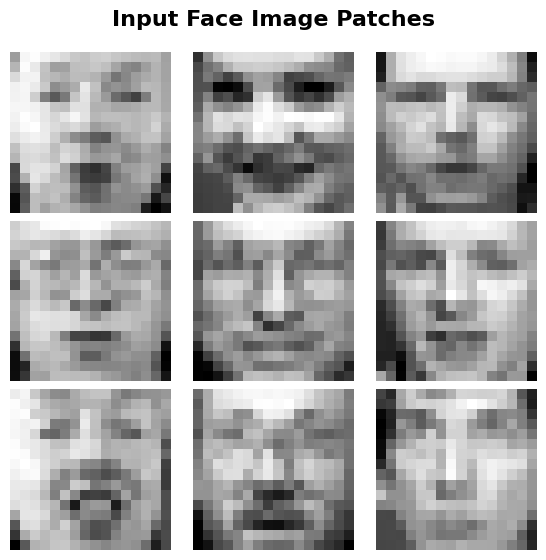

In [3]:
# 1. Configuration
patch_size = (16, 16)
n_samples_to_plot = 9
title = "Input Face Image Patches"

# 2. Select 9 random indices
# Assuming X_patches is (patch_dim, n_samples)
n_total_patches = X_patches.shape[1]
random_indices = np.random.choice(n_total_patches, n_samples_to_plot, replace=False)

# 3. Setup 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
fig.suptitle(title, fontsize=16, fontweight='bold', y=0.95)

for i, idx in enumerate(random_indices):
    ax = axes.flatten()[i]
    
    # Reshape the column back to 2D
    patch = X_patches[:, idx].reshape(patch_size)
    
    ax.imshow(patch, cmap="gray", interpolation='nearest')
    ax.axis('off')

# 4. Minimize whitespace between patches
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.95, bottom=0.05, top=0.88)
plt.show()

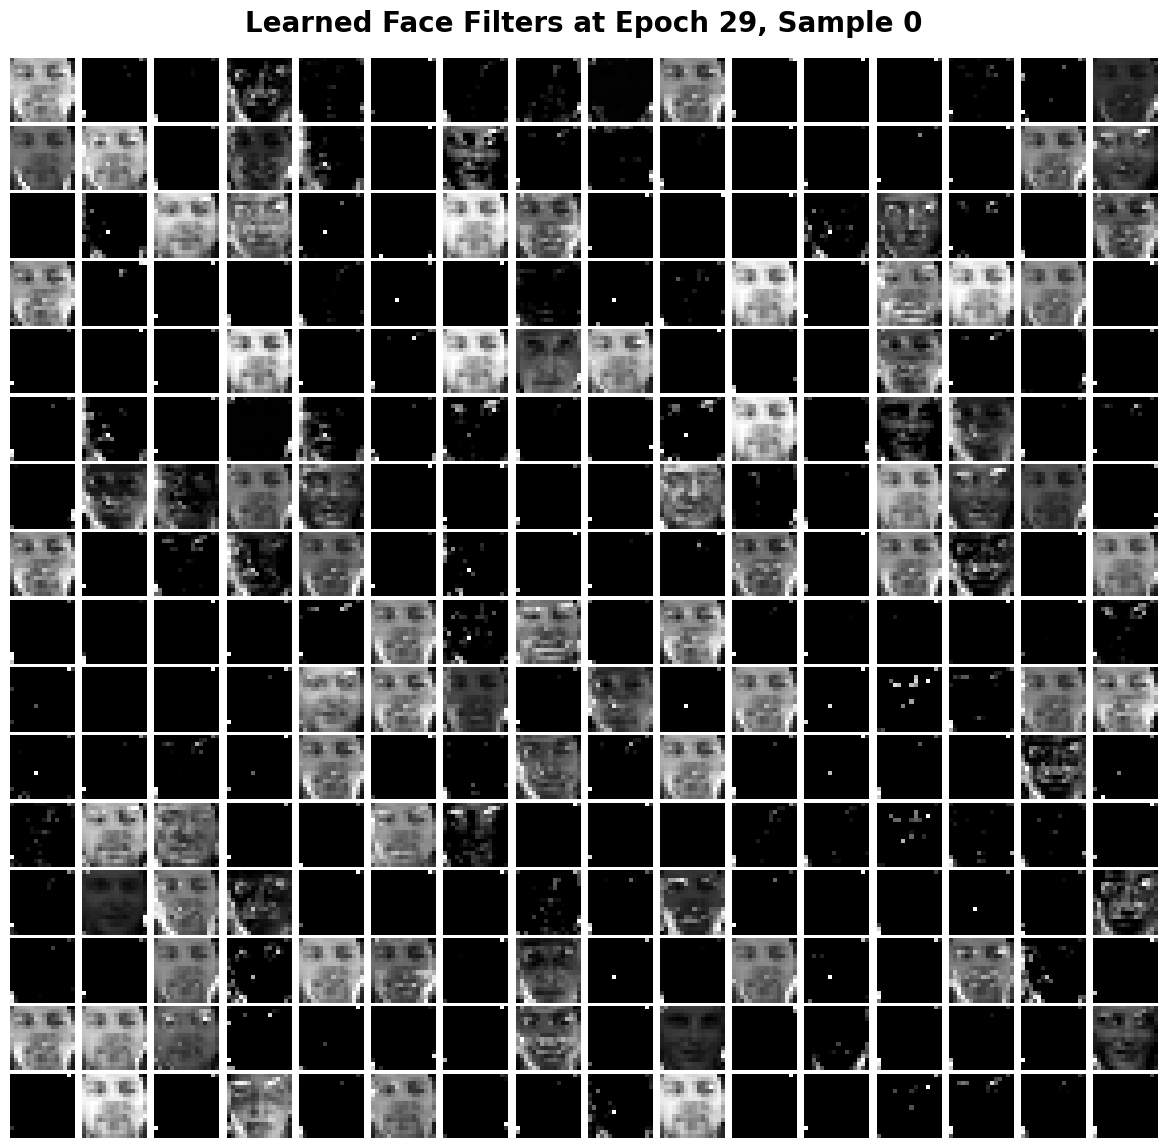

  7%|██████▋                                                                                            | 27/400 [00:08<00:59,  6.29it/s]

In [ ]:
seed = 100
np.random.seed(seed)
NumberofSources = int(16*16)
NumberofMixtures = int(16*16)
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "nnantisparse",
                ### Optimization parameters
                "lambda_lateral" : 1 - 1e-2,
                "gamma_predictive" : 5,
                ### Learning rates 
                "lr_W" : 3e-3,
                "neural_lr_start" : 0.1,
                "neural_lr_stop" : 1e-6,
                "stlambda_lr" : 5e-2,
                "neural_dynamics_iterations" : 500,
                "neural_OUTPUT_COMP_TOL" : 1e-6,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "constant",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_slow_loop_index",
                "neural_lr_decay_divider" : 100,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                "image_shape":(16, 16),
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : None,
                "debug_iteration_point" : 400,
                "plot_debug_during_training" : True,
}
model = PredictiveEntropyFaceNMF(**hyperparam_dict)
model.C_y = np.eye(NumberofSources) / 1. + np.random.randn(NumberofSources, NumberofSources) / 250
model.W = np.eye(NumberofSources, NumberofMixtures) * 1.0 + np.random.randn(NumberofSources, NumberofMixtures) / 250
model.fit(X_patches, n_epochs = 100)